In [1]:
from aoespy import *
import xarray as xr
dir='/nobackupp27/afahad/exp/IAU_exp/'
data='/nobackupp27/afahad/project/initialization_shock/data/'

/home6/afahad/.local/lib/python3.9/site-packages/aoespy.py:19: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [3]:
RP506=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_RP0506/holding/geosgcm_surf/200505/*surf*200505*z.nc4')
RP5062=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_RP0506/holding/geosgcm_surf/200506/*surf*200506*z.nc4')
RP5063=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_RP0506/holding/geosgcm_surf/200507/*surf*200507*z.nc4')
RP506=xr.concat([RP506,RP5062,RP5063],dim='time')
RP506P=RP506.PRECTOT.compute()
RP506P=RP506P*86400


In [4]:
ME506=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_ME0506/holding/geosgcm_surf/200505/*surf*200505*z.nc4')
ME5062=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_ME0506/holding/geosgcm_surf/200506/*surf*200506*z.nc4')
ME5063=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_ME0506/holding/geosgcm_surf/200507/*surf*200507*z.nc4')
ME506=xr.concat([ME506,ME5062,ME5063],dim='time')
ME506P=ME506.PRECTOT.compute()
ME506P=ME506P*86400

In [5]:
# RP506P.to_netcdf('RP506P.nc4')
# ME506P.to_netcdf('ME506P.nc4')

In [6]:
RP506P=RP506P.sel(time=slice('2005-05-05','2005-06-30'))
ME506P=ME506P.sel(time=slice('2005-05-05','2005-06-30'))

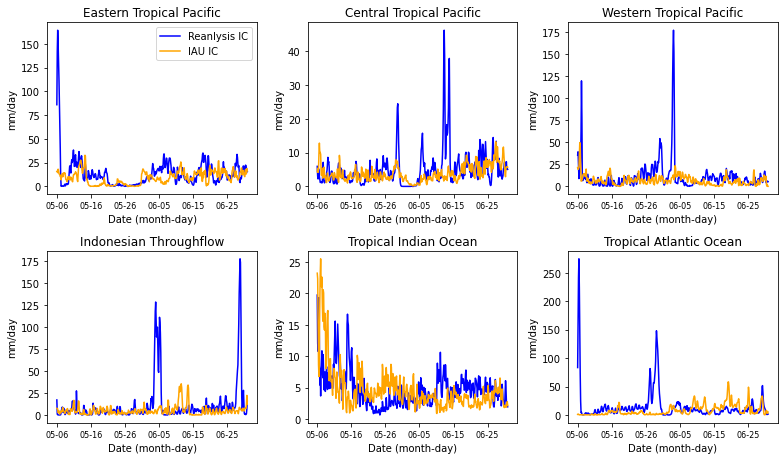

In [7]:
ticks = []

for i in range(len(ME506P.time)):
    ticks.append(str(ME506P.time.data[i])[5:10])

x1 = -127
x2 = -127
y1 = 7
y2 = 7

plt.figure(figsize=(11, 6.5))

plt.subplot(2, 3, 1)
plt.plot((ME506P).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='blue')
plt.plot((RP506P).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='orange')
plt.title('Eastern Tropical Pacific')
plt.xticks(arange(len(ticks))[::80], ticks[::80], fontsize=8)
plt.legend(['Reanlysis IC', 'IAU IC'])
plt.xlabel('Date (month-day)')
plt.ylabel('mm/day')

x1 = -178
x2 = -178
y1 = 2
y2 = 2

plt.subplot(2, 3, 2)
plt.plot((ME506P).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='blue')
plt.plot((RP506P).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='orange')
plt.title('Central Tropical Pacific')
plt.xticks(arange(len(ticks))[::80], ticks[::80], fontsize=8)
plt.xlabel('Date (month-day)')
plt.ylabel('mm/day')

x1 = 143
x2 = 143
y1 = -1
y2 = -1

plt.subplot(2, 3, 3)
plt.plot((ME506P).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='blue')
plt.plot((RP506P).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='orange')
plt.title('Western Tropical Pacific')
plt.xticks(arange(len(ticks))[::80], ticks[::80], fontsize=8)
plt.xlabel('Date (month-day)')
plt.ylabel('mm/day')



x1 = 122
x2 = 123
y1 = 2
y2 = 2

plt.subplot(2, 3, 4)
plt.plot((ME506P).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='blue')
plt.plot((RP506P).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='orange')
plt.title('Indonesian Throughflow')
plt.xticks(arange(len(ticks))[::80], ticks[::80], fontsize=8)
plt.xlabel('Date (month-day)')
plt.ylabel('mm/day')


x1 = 89
x2 = 92
y1 = 7
y2 = 8

plt.subplot(2, 3, 5)
plt.plot((ME506P).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='blue')
plt.plot((RP506P).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='orange')
plt.title('Tropical Indian Ocean')
plt.xticks(arange(len(ticks))[::80], ticks[::80], fontsize=8)
plt.xlabel('Date (month-day)')
plt.ylabel('mm/day')

x1 = -39
x2 = -38
y1 = 7
y2 = 8

plt.subplot(2, 3, 6)
plt.plot((ME506P).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='blue')
plt.plot((RP506P).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='orange')
plt.title('Tropical Atlantic Ocean')
plt.xticks(arange(len(ticks))[::80], ticks[::80], fontsize=8)
plt.xlabel('Date (month-day)')
plt.ylabel('mm/day')

plt.tight_layout()
#plt.savefig('spike_pr.png',dpi=150)